### 1.- **librerías y rutas**


In [3]:
import os
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

print("Versión de TensorFlow:", tf.__version__)

# Definir las rutas base según tu estructura de directorios
base_dir = './imagenes-satelitales'

# Rutas de entrenamiento y prueba
train_dir = os.path.join(base_dir, 'seg_train/seg_train')
test_dir = os.path.join(base_dir, 'seg_test/seg_test')
pred_dir = os.path.join(base_dir, 'seg_pred/seg_pred')

# Clases del dataset
classes = ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']

print("Rutas configuradas correctamente.")

Versión de TensorFlow: 2.21.0
Rutas configuradas correctamente.


Fase 1 - Análisis Exploratorio (Conteo y Distribución)

--- CONJUNTO DE ENTRENAMIENTO ---
Total de imágenes de buildings: 2191
Total de imágenes de forest: 2271
Total de imágenes de glacier: 2404
Total de imágenes de mountain: 2512
Total de imágenes de sea: 2274
Total de imágenes de street: 2382

--- CONJUNTO DE PRUEBA ---
Total de imágenes de buildings: 437
Total de imágenes de forest: 474
Total de imágenes de glacier: 553
Total de imágenes de mountain: 525
Total de imágenes de sea: 510
Total de imágenes de street: 501

Total general entrenamiento: 14034
Total general prueba: 3000


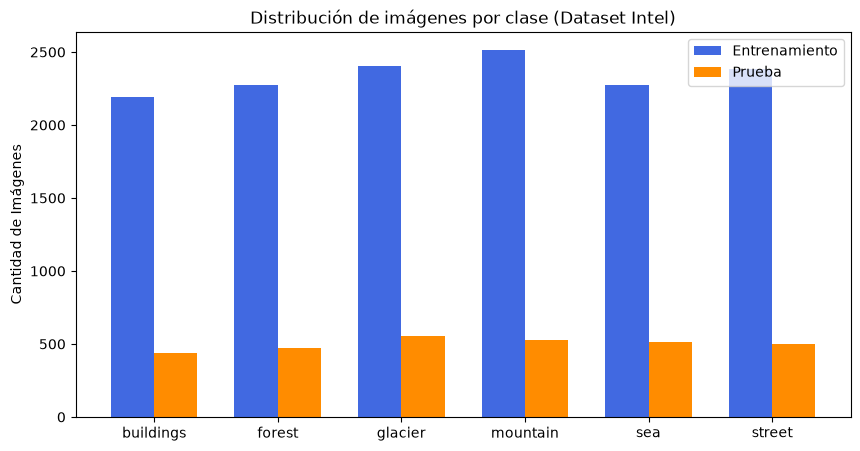

In [4]:
# Diccionarios para almacenar el conteo
train_counts = {}
test_counts = {}

# Contar imágenes en el conjunto de entrenamiento
print("--- CONJUNTO DE ENTRENAMIENTO ---")
for cls in classes:
    path = os.path.join(train_dir, cls)
    count = len(os.listdir(path))
    train_counts[cls] = count
    print(f"Total de imágenes de {cls}: {count}")

# Contar imágenes en el conjunto de prueba
print("\n--- CONJUNTO DE PRUEBA ---")
for cls in classes:
    path = os.path.join(test_dir, cls)
    count = len(os.listdir(path))
    test_counts[cls] = count
    print(f"Total de imágenes de {cls}: {count}")

print(f"\nTotal general entrenamiento: {sum(train_counts.values())}")
print(f"Total general prueba: {sum(test_counts.values())}")

# Graficar la distribución
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(classes))
width = 0.35

ax.bar(x - width/2, list(train_counts.values()), width, label='Entrenamiento', color='royalblue')
ax.bar(x + width/2, list(test_counts.values()), width, label='Prueba', color='darkorange')

ax.set_ylabel('Cantidad de Imágenes')
ax.set_title('Distribución de imágenes por clase (Dataset Intel)')
ax.set_xticks(x)
ax.set_xticklabels(classes)
ax.legend()

plt.show()

Fase 1.1 - Inspección Visual de las Clases

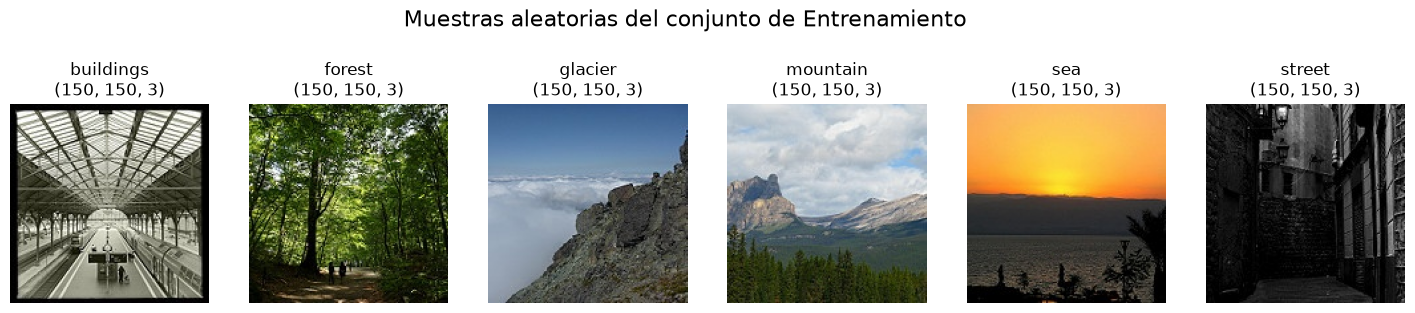

In [5]:
import random

def show_random_samples(directory, classes):
    plt.figure(figsize=(18, 4))
    
    for i, cls in enumerate(classes):
        class_path = os.path.join(directory, cls)
        # Obtener un archivo aleatorio de la clase
        random_image = random.choice(os.listdir(class_path))
        img_path = os.path.join(class_path, random_image)
        
        # Leer y mostrar la imagen
        img = mpimg.imread(img_path)
        plt.subplot(1, len(classes), i + 1)
        plt.imshow(img)
        plt.title(f"{cls}\n{img.shape}")
        plt.axis('off')
        
    plt.suptitle("Muestras aleatorias del conjunto de Entrenamiento", fontsize=16)
    plt.show()

# Ejecutar visualización
show_random_samples(train_dir, classes)

Fase 2 - Preprocesamiento y Data Augmentation

In [6]:
# 1. Configuración de los Generadores (Data Augmentation solo para Train)
train_datagen = ImageDataGenerator(
    rescale=1.0/255.,
    rotation_range=15,       # Rotación aleatoria de +-15 grados
    width_shift_range=0.1,   # Traslación horizontal
    height_shift_range=0.1,  # Traslación vertical
    zoom_range=0.1,          # Zoom aleatorio
    horizontal_flip=True,    # Volteo horizontal aleatorio
    fill_mode='nearest'
)

# Para prueba SOLO reescalamos (no se aumentan los datos de prueba)
test_datagen = ImageDataGenerator(rescale=1.0/255.)

# 2. Carga de imágenes desde los directorios
print("Cargando conjunto de entrenamiento:")
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(150, 150),
    batch_size=32,
    class_mode='categorical' # Categórico porque son 6 clases
)

print("\nCargando conjunto de prueba:")
test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(150, 150),
    batch_size=32,
    class_mode='categorical',
    shuffle=False # No mezclar para evaluar matrices de confusión más adelante
)

# Verificar la asignación de índices a clases
print("\nÍndices de las clases asignados por el generador:")
print(train_generator.class_indices)

Cargando conjunto de entrenamiento:
Found 14034 images belonging to 6 classes.

Cargando conjunto de prueba:
Found 3000 images belonging to 6 classes.

Índices de las clases asignados por el generador:
{'buildings': 0, 'forest': 1, 'glacier': 2, 'mountain': 3, 'sea': 4, 'street': 5}


Fase 3 - Definición de la Arquitectura Custom CNN

In [7]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

# 1. Definir la arquitectura secuencial
model_custom = Sequential([
    # Primer bloque convolucional
    Conv2D(32, (3,3), activation='relu', input_shape=(150, 150, 3)),
    MaxPooling2D(2, 2),
    
    # Segundo bloque convolucional
    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2, 2),
    
    # Tercer bloque convolucional
    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2, 2),
    
    # Cuarto bloque convolucional
    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2, 2),
    
    # Aplanamiento y capas densas
    Flatten(),
    Dropout(0.5), # Apaga el 50% de las neuronas aleatoriamente para evitar sobreajuste
    Dense(512, activation='relu'),
    
    # Capa de salida: 6 neuronas (por las 6 clases) y activación softmax
    Dense(6, activation='softmax')
])

# Mostrar el resumen de la arquitectura
model_custom.summary()

/mnt/c/Users/USUARIO/OneDrive/Documentos/python/image-scene-classification/wsl_env_312/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 15, 15, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 512)            │     3,211,776 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 6)              │         3,078 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,455,686 (13.18 MB)

 Trainable params: 3,455,686 (13.18 MB)

 Non-trainable params: 0 (0.00 B)

Fase 3.1 - Compilación y Callbacks

In [8]:
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# Compilar el modelo
model_custom.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss='categorical_crossentropy', # Categórica porque son > 2 clases
    metrics=['accuracy']
)

# Definir los callbacks (parada temprana y guardado del mejor modelo)
callbacks = [
    EarlyStopping(
        monitor='val_loss', 
        patience=5, # Se detiene si no mejora en 5 épocas
        restore_best_weights=True
    ),
    ModelCheckpoint(
        'custom_cnn_best.keras', 
        monitor='val_loss', 
        save_best_only=True,
        verbose=1
    )
]
print("Modelo compilado y callbacks configurados.")

Modelo compilado y callbacks configurados.


ResNet50 Sin Transfer Learning (Desde Cero)

In [11]:
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
import matplotlib.pyplot as plt
import os
os.environ['TF_GPU_ALLOCATOR'] = 'cuda_malloc_async'

print("Cargando ResNet50 SIN Transfer Learning (Desde cero)...")

# 1. Cargar ResNet50 en blanco (weights=None)
base_model_resnet_scratch = ResNet50(
    weights=None, 
    include_top=False, 
    input_shape=(150, 150, 3)
)

# Queremos que toda la red aprenda desde cero
base_model_resnet_scratch.trainable = True 

# 2. Construir el modelo
model_resnet_scratch = Sequential([
    base_model_resnet_scratch,
    GlobalAveragePooling2D(),
    Dropout(0.5),
    Dense(6, activation='softmax')
])

# 3. Compilar
model_resnet_scratch.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# 4. Callbacks
callbacks_resnet_scratch = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    ModelCheckpoint('resnet50_scratch_best.keras', monitor='val_loss', save_best_only=True, verbose=1)
]

print("Iniciando entrenamiento de ResNet50 Sin Transfer Learning...")

# 5. Entrenamiento
history_resnet_scratch = model_resnet_scratch.fit(
    train_generator,
    epochs=20,
    validation_data=test_generator,
    callbacks=callbacks_resnet_scratch,
    verbose=1
)
print("¡Entrenamiento finalizado!")

Cargando ResNet50 SIN Transfer Learning (Desde cero)...
Iniciando entrenamiento de ResNet50 Sin Transfer Learning...
Epoch 1/20


I0000 00:00:1784691854.373019   59829 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_95532__.397


231/439 ━━━━━━━━━━━━━━━━━━━━ 2:20 677ms/step - accuracy: 0.3971 - loss: 1.9072

I0000 00:00:1784692036.961869   59828 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_95532__.397


439/439 ━━━━━━━━━━━━━━━━━━━━ 0s 676ms/step - accuracy: 0.4634 - loss: 1.6710
Epoch 1: val_loss improved from None to 2.89198, saving model to resnet50_scratch_best.keras

Epoch 1: finished saving model to resnet50_scratch_best.keras
439/439 ━━━━━━━━━━━━━━━━━━━━ 432s 836ms/step - accuracy: 0.4634 - loss: 1.6710 - val_accuracy: 0.2890 - val_loss: 2.8920
Epoch 2/20
439/439 ━━━━━━━━━━━━━━━━━━━━ 0s 425ms/step - accuracy: 0.6112 - loss: 1.1325
Epoch 2: val_loss improved from 2.89198 to 1.89083, saving model to resnet50_scratch_best.keras

Epoch 2: finished saving model to resnet50_scratch_best.keras
439/439 ━━━━━━━━━━━━━━━━━━━━ 210s 477ms/step - accuracy: 0.6112 - loss: 1.1325 - val_accuracy: 0.4510 - val_loss: 1.8908
Epoch 3/20
439/439 ━━━━━━━━━━━━━━━━━━━━ 0s 425ms/step - accuracy: 0.6832 - loss: 0.8533
Epoch 3: val_loss improved from 1.89083 to 1.07158, saving model to resnet50_scratch_best.keras

Epoch 3: finished saving model to resnet50_scratch_best.keras
439/439 ━━━━━━━━━━━━━━━━━━━━ 23

Gráficas de ResNet50 (Desde Cero)

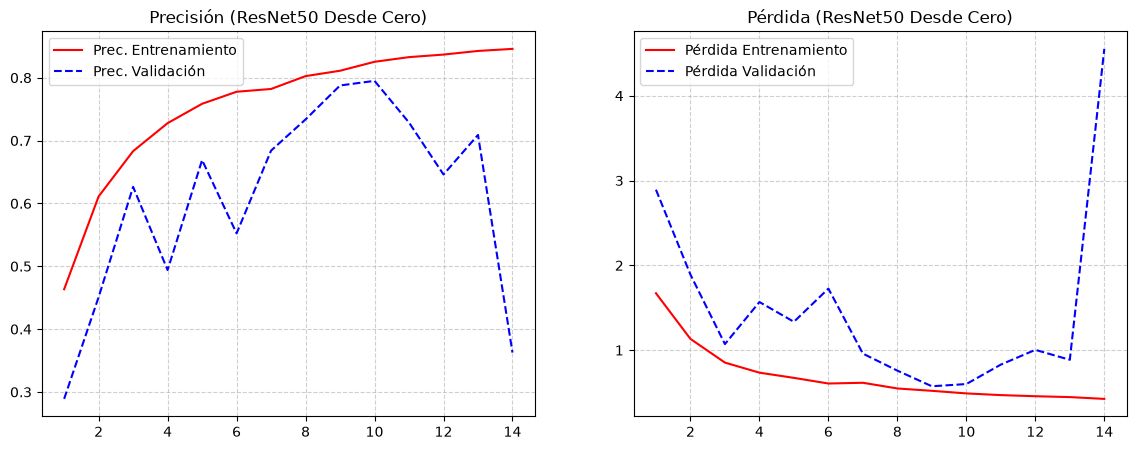

In [12]:
# Extraer datos
acc = history_resnet_scratch.history['accuracy']
val_acc = history_resnet_scratch.history['val_accuracy']
loss = history_resnet_scratch.history['loss']
val_loss = history_resnet_scratch.history['val_loss']
epochs_range = range(1, len(acc) + 1)

plt.figure(figsize=(14, 5))

# Precisión
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, 'r-', label='Prec. Entrenamiento')
plt.plot(epochs_range, val_acc, 'b--', label='Prec. Validación')
plt.title('Precisión (ResNet50 Desde Cero)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

# Pérdida
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, 'r-', label='Pérdida Entrenamiento')
plt.plot(epochs_range, val_loss, 'b--', label='Pérdida Validación')
plt.title('Pérdida (ResNet50 Desde Cero)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

plt.show()

Resumen de las métricas de clasificación de los modelos entrenados desde cero

In [13]:
import numpy as np
from sklearn.metrics import precision_recall_fscore_support, accuracy_score

print("Procesando métricas para la Tabla de Modelo Desde Cero...")

# 1. Obtener predicciones del modelo DESDE CERO
test_generator.reset()
Y_pred_scratch = model_resnet_scratch.predict(test_generator, verbose=0)
y_pred_scratch = np.argmax(Y_pred_scratch, axis=1)
y_true = test_generator.classes

# 2. Calcular métricas
acc_test_scratch = accuracy_score(y_true, y_pred_scratch)
prec_scratch, rec_scratch, f1_scratch, _ = precision_recall_fscore_support(y_true, y_pred_scratch, average='macro')

# 3. Extraer el Accuracy de Entrenamiento y Validación de la mejor época
best_epoch_scratch = np.argmax(history_resnet_scratch.history['val_accuracy'])
acc_train_scratch = history_resnet_scratch.history['accuracy'][best_epoch_scratch]
acc_val_scratch = history_resnet_scratch.history['val_accuracy'][best_epoch_scratch]
total_epochs_scratch = len(history_resnet_scratch.history['loss'])

# 4. Imprimir para la tabla
print("\n" + "="*70)
print("TABLA 2: Resumen de las métricas de los modelos entrenados DESDE CERO")
print("="*70)
print(f"Modelo                : ResNet50 (Scratch)")
print(f"Learning rate         : 1e-4")
print(f"Epocas                : {total_epochs_scratch} (Mejor época: {best_epoch_scratch + 1})")
print(f"Optimizador           : Adam")
print(f"Accuracy Entrenamiento: {acc_train_scratch:.4f}")
print(f"Accuracy Validación   : {acc_val_scratch:.4f}")
print(f"Accuracy Prueba       : {acc_test_scratch:.4f}")
print(f"Precision (macro)     : {prec_scratch:.4f}")
print(f"Recall (macro)        : {rec_scratch:.4f}")
print(f"F1-score (macro)      : {f1_scratch:.4f}")
print("="*70)

Procesando métricas para la Tabla de Modelo Desde Cero...

TABLA 2: Resumen de las métricas de los modelos entrenados DESDE CERO
Modelo                : ResNet50 (Scratch)
Learning rate         : 1e-4
Epocas                : 14 (Mejor época: 10)
Optimizador           : Adam
Accuracy Entrenamiento: 0.8254
Accuracy Validación   : 0.7950
Accuracy Prueba       : 0.7877
Precision (macro)     : 0.8000
Recall (macro)        : 0.7935
F1-score (macro)      : 0.7894


ResNet50 Con Transfer Learning (Feature Extraction)

In [14]:
print("Cargando ResNet50 CON Transfer Learning...")

# 1. Cargar pesos de ImageNet
base_model_resnet_tl = ResNet50(
    weights='imagenet', 
    include_top=False, 
    input_shape=(150, 150, 3)
)

# 2. Congelar el modelo base
base_model_resnet_tl.trainable = False

# 3. Construir el nuevo modelo
model_resnet_tl = Sequential([
    base_model_resnet_tl,
    GlobalAveragePooling2D(),
    Dropout(0.5),
    Dense(6, activation='softmax')
])

# 4. Compilar
model_resnet_tl.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# 5. Callbacks
callbacks_resnet_tl = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    ModelCheckpoint('resnet50_tl_best.keras', monitor='val_loss', save_best_only=True, verbose=1)
]

print("Iniciando entrenamiento (Feature Extraction)...")

# 6. Entrenamiento
history_resnet_tl = model_resnet_tl.fit(
    train_generator,
    epochs=15, 
    validation_data=test_generator,
    callbacks=callbacks_resnet_tl,
    verbose=1
)
print("¡Entrenamiento Transfer Learning finalizado!")

Cargando ResNet50 CON Transfer Learning...
94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 10s 0us/step
Iniciando entrenamiento (Feature Extraction)...
Epoch 1/15


I0000 00:00:1784694981.910080   59831 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_160275__.185


361/439 ━━━━━━━━━━━━━━━━━━━━ 25s 321ms/step - accuracy: 0.1827 - loss: 1.9607

I0000 00:00:1784695103.135620   59827 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_160275__.185


439/439 ━━━━━━━━━━━━━━━━━━━━ 0s 341ms/step - accuracy: 0.1815 - loss: 1.9446
Epoch 1: val_loss improved from None to 1.75934, saving model to resnet50_tl_best.keras

Epoch 1: finished saving model to resnet50_tl_best.keras
439/439 ━━━━━━━━━━━━━━━━━━━━ 193s 414ms/step - accuracy: 0.1815 - loss: 1.9446 - val_accuracy: 0.3003 - val_loss: 1.7593
Epoch 2/15
439/439 ━━━━━━━━━━━━━━━━━━━━ 0s 341ms/step - accuracy: 0.1990 - loss: 1.8163
Epoch 2: val_loss improved from 1.75934 to 1.72829, saving model to resnet50_tl_best.keras

Epoch 2: finished saving model to resnet50_tl_best.keras
439/439 ━━━━━━━━━━━━━━━━━━━━ 173s 393ms/step - accuracy: 0.1990 - loss: 1.8163 - val_accuracy: 0.2917 - val_loss: 1.7283
Epoch 3/15
439/439 ━━━━━━━━━━━━━━━━━━━━ 0s 343ms/step - accuracy: 0.2254 - loss: 1.7690
Epoch 3: val_loss improved from 1.72829 to 1.70293, saving model to resnet50_tl_best.keras

Epoch 3: finished saving model to resnet50_tl_best.keras
439/439 ━━━━━━━━━━━━━━━━━━━━ 203s 395ms/step - accuracy: 0.22

ResNet50 Con Fine-Tuning

In [15]:
print("Preparando ResNet50 para Fine-Tuning...")

# 1. Descongelar temporalmente todo
base_model_resnet_tl.trainable = True

# 2. Congelar todo EXCEPTO las capas del último bloque ('conv5_block')
for layer in base_model_resnet_tl.layers:
    if layer.name.startswith('conv5_block'):
        layer.trainable = True
    else:
        layer.trainable = False

# 3. Re-compilar con learning rate muy bajo (1e-5)
model_resnet_tl.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# 4. Callbacks
callbacks_resnet_ft = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    ModelCheckpoint('resnet50_finetuning_best.keras', monitor='val_loss', save_best_only=True, verbose=1)
]

print("Iniciando entrenamiento de Fine-Tuning...")

# 5. Entrenamiento
history_resnet_ft = model_resnet_tl.fit(
    train_generator,
    epochs=15, 
    validation_data=test_generator,
    callbacks=callbacks_resnet_ft,
    verbose=1
)
print("¡Fine-Tuning con ResNet50 finalizado!")

Preparando ResNet50 para Fine-Tuning...
Iniciando entrenamiento de Fine-Tuning...
Epoch 1/15


I0000 00:00:1784697611.458015   59831 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_230848__.225


 70/439 ━━━━━━━━━━━━━━━━━━━━ 1:57 319ms/step - accuracy: 0.3424 - loss: 3.0960

I0000 00:00:1784697643.467720   59828 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_230848__.225


439/439 ━━━━━━━━━━━━━━━━━━━━ 0s 351ms/step - accuracy: 0.5219 - loss: 1.4201
Epoch 1: val_loss improved from None to 0.94435, saving model to resnet50_finetuning_best.keras

Epoch 1: finished saving model to resnet50_finetuning_best.keras
439/439 ━━━━━━━━━━━━━━━━━━━━ 207s 423ms/step - accuracy: 0.5219 - loss: 1.4201 - val_accuracy: 0.6470 - val_loss: 0.9444
Epoch 2/15
439/439 ━━━━━━━━━━━━━━━━━━━━ 0s 340ms/step - accuracy: 0.6336 - loss: 0.9355
Epoch 2: val_loss improved from 0.94435 to 0.76432, saving model to resnet50_finetuning_best.keras

Epoch 2: finished saving model to resnet50_finetuning_best.keras
439/439 ━━━━━━━━━━━━━━━━━━━━ 172s 392ms/step - accuracy: 0.6336 - loss: 0.9355 - val_accuracy: 0.7137 - val_loss: 0.7643
Epoch 3/15
439/439 ━━━━━━━━━━━━━━━━━━━━ 0s 339ms/step - accuracy: 0.6699 - loss: 0.8533
Epoch 3: val_loss improved from 0.76432 to 0.73369, saving model to resnet50_finetuning_best.keras

Epoch 3: finished saving model to resnet50_finetuning_best.keras
439/439 ━━━━━

Métricas y Matriz de Confusión (ResNet50)

Evaluando ResNet50 (Fine-Tuned) en el conjunto de prueba...
94/94 ━━━━━━━━━━━━━━━━━━━━ 32s 290ms/step

REPORTE DE CLASIFICACIÓN - RESNET50 (FINE-TUNING)
              precision    recall  f1-score   support

   buildings     0.7324    0.8078    0.7682       437
      forest     0.8867    0.9578    0.9209       474
     glacier     0.7412    0.6890    0.7142       553
    mountain     0.7494    0.6324    0.6860       525
         sea     0.6944    0.7843    0.7366       510
      street     0.8436    0.7964    0.8193       501

    accuracy                         0.7730      3000
   macro avg     0.7746    0.7779    0.7742      3000
weighted avg     0.7735    0.7730    0.7711      3000



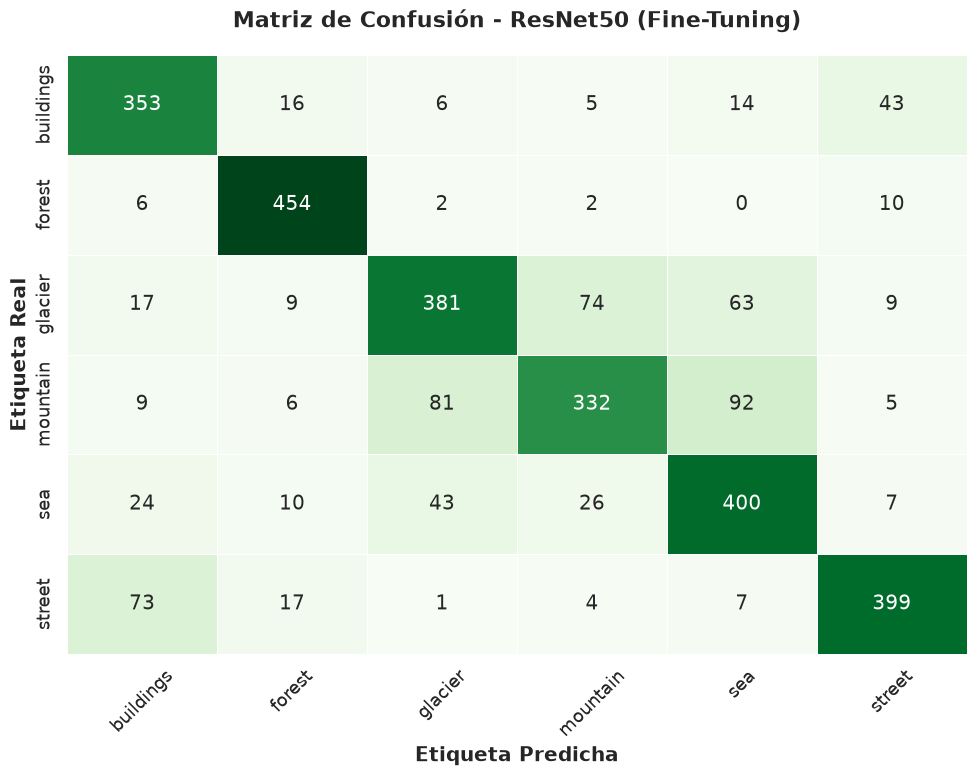

In [16]:
import numpy as np
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

print("Evaluando ResNet50 (Fine-Tuned) en el conjunto de prueba...")

# 1. Reiniciar generador
test_generator.reset()

# 2. Obtener predicciones
Y_pred_resnet = model_resnet_tl.predict(test_generator, verbose=1)
y_pred_resnet = np.argmax(Y_pred_resnet, axis=1)
y_true = test_generator.classes
nombres_clases = list(test_generator.class_indices.keys())

# 3. Reporte de Clasificación (Para tu Tabla 3)
print("\n" + "="*50)
print("REPORTE DE CLASIFICACIÓN - RESNET50 (FINE-TUNING)")
print("="*50)
print(classification_report(y_true, y_pred_resnet, target_names=nombres_clases, digits=4))

# 4. Matriz de Confusión
cm_resnet = confusion_matrix(y_true, y_pred_resnet)

plt.figure(figsize=(10, 8))
sns.set(font_scale=1.2)
sns.heatmap(
    cm_resnet, 
    annot=True, 
    fmt='d', 
    cmap='Greens', # Usamos verde para diferenciarla de VGG16 en tu artículo
    xticklabels=nombres_clases, 
    yticklabels=nombres_clases,
    linewidths=.5,
    cbar=False
)

plt.ylabel('Etiqueta Real', fontweight='bold')
plt.xlabel('Etiqueta Predicha', fontweight='bold')
plt.title('Matriz de Confusión - ResNet50 (Fine-Tuning)', fontsize=16, fontweight='bold', pad=20)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Resultados del modelo Preentrenado

In [17]:
import numpy as np
from sklearn.metrics import precision_recall_fscore_support, accuracy_score

print("Procesando métricas para la Tabla de Modelo Preentrenado (Fine-Tuning)...")

# 1. Obtener predicciones del modelo FINE-TUNING
test_generator.reset()
Y_pred_tl = model_resnet_tl.predict(test_generator, verbose=0)
y_pred_tl = np.argmax(Y_pred_tl, axis=1)
y_true = test_generator.classes

# 2. Calcular métricas
acc_test_tl = accuracy_score(y_true, y_pred_tl)
prec_tl, rec_tl, f1_tl, _ = precision_recall_fscore_support(y_true, y_pred_tl, average='macro')

# 3. Extraer el Accuracy de Entrenamiento y Validación de la mejor época del Fine-Tuning
best_epoch_tl = np.argmax(history_resnet_ft.history['val_accuracy'])
acc_train_tl = history_resnet_ft.history['accuracy'][best_epoch_tl]
acc_val_tl = history_resnet_ft.history['val_accuracy'][best_epoch_tl]
total_epochs_tl = len(history_resnet_ft.history['loss'])

# 4. Imprimir para la tabla
print("\n" + "="*70)
print("TABLA 1: Resumen de las métricas del modelo PREENTRENADO (Fine-Tuning)")
print("="*70)
print(f"Modelo                : ResNet50 (Fine-Tuning)")
print(f"Image Batch           : {test_generator.batch_size}") 
print(f"Epocas                : {total_epochs_tl} (Mejor época: {best_epoch_tl + 1})")
print(f"Optimizador           : Adam (lr=1e-5)")
print(f"Accuracy Entrenamiento: {acc_train_tl:.4f}")
print(f"Accuracy Validación   : {acc_val_tl:.4f}")
print(f"Accuracy Prueba       : {acc_test_tl:.4f}")
print(f"Precision (macro)     : {prec_tl:.4f}")
print(f"Recall (macro)        : {rec_tl:.4f}")
print(f"F1-score (macro)      : {f1_tl:.4f}")
print("="*70)

Procesando métricas para la Tabla de Modelo Preentrenado (Fine-Tuning)...

TABLA 1: Resumen de las métricas del modelo PREENTRENADO (Fine-Tuning)
Modelo                : ResNet50 (Fine-Tuning)
Image Batch           : 32
Epocas                : 15 (Mejor época: 11)
Optimizador           : Adam (lr=1e-5)
Accuracy Entrenamiento: 0.7425
Accuracy Validación   : 0.7730
Accuracy Prueba       : 0.7730
Precision (macro)     : 0.7746
Recall (macro)        : 0.7779
F1-score (macro)      : 0.7742


VGG16 Sin Transfer Learning (Desde Cero)

In [10]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
import matplotlib.pyplot as plt

import os

# Parche para evitar el error Out of Memory en la GPU
os.environ['TF_GPU_ALLOCATOR'] = 'cuda_malloc_async'

print("Cargando VGG16 SIN Transfer Learning (Desde cero)...")

# 1. Cargar VGG16 en blanco (weights=None)
base_model_vgg_scratch = VGG16(
    weights=None, 
    include_top=False, 
    input_shape=(150, 150, 3)
)

# Queremos que toda la red aprenda desde cero
base_model_vgg_scratch.trainable = True 

# 2. Construir el modelo
model_vgg_scratch = Sequential([
    base_model_vgg_scratch,
    GlobalAveragePooling2D(),
    Dropout(0.5),
    Dense(6, activation='softmax')
])

# 3. Compilar
model_vgg_scratch.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# 4. Callbacks
callbacks_vgg_scratch = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    ModelCheckpoint('vgg16_scratch_best.keras', monitor='val_loss', save_best_only=True, verbose=1)
]

print("Iniciando entrenamiento de VGG16 Sin Transfer Learning...")

# 5. Entrenamiento
history_vgg_scratch = model_vgg_scratch.fit(
    train_generator,
    epochs=20,
    validation_data=test_generator,
    callbacks=callbacks_vgg_scratch,
    verbose=1
)
print("¡Entrenamiento finalizado!")

Cargando VGG16 SIN Transfer Learning (Desde cero)...
Iniciando entrenamiento de VGG16 Sin Transfer Learning...
Epoch 1/20


I0000 00:00:1784778273.696961    4597 service.cc:153] XLA service 0x79116c0554f0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1784778273.697000    4597 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 3050 6GB Laptop GPU, Compute Capability 8.6 (Driver: 13.0.0; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.25.0)
I0000 00:00:1784778273.953671    4597 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1784778275.098008    4597 cuda_dnn.cc:461] Loaded cuDNN version 92500
I0000 00:00:1784778275.367109    4597 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_8288__.70
I0000 00:00:1784778343.111580    4597 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


171/439 ━━━━━━━━━━━━━━━━━━━━ 2:12 496ms/step - accuracy: 0.3628 - loss: 1.4563

I0000 00:00:1784778428.672728    4595 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_8288__.70


439/439 ━━━━━━━━━━━━━━━━━━━━ 0s 563ms/step - accuracy: 0.4694 - loss: 1.2553
Epoch 1: val_loss improved from None to 0.95735, saving model to vgg16_scratch_best.keras

Epoch 1: finished saving model to vgg16_scratch_best.keras
439/439 ━━━━━━━━━━━━━━━━━━━━ 393s 728ms/step - accuracy: 0.4694 - loss: 1.2553 - val_accuracy: 0.5907 - val_loss: 0.9573
Epoch 2/20
439/439 ━━━━━━━━━━━━━━━━━━━━ 0s 587ms/step - accuracy: 0.6279 - loss: 0.9339
Epoch 2: val_loss improved from 0.95735 to 0.85965, saving model to vgg16_scratch_best.keras

Epoch 2: finished saving model to vgg16_scratch_best.keras
439/439 ━━━━━━━━━━━━━━━━━━━━ 315s 714ms/step - accuracy: 0.6279 - loss: 0.9339 - val_accuracy: 0.6713 - val_loss: 0.8596
Epoch 3/20
439/439 ━━━━━━━━━━━━━━━━━━━━ 0s 515ms/step - accuracy: 0.7050 - loss: 0.7781
Epoch 3: val_loss improved from 0.85965 to 0.75950, saving model to vgg16_scratch_best.keras

Epoch 3: finished saving model to vgg16_scratch_best.keras
439/439 ━━━━━━━━━━━━━━━━━━━━ 268s 611ms/step - ac

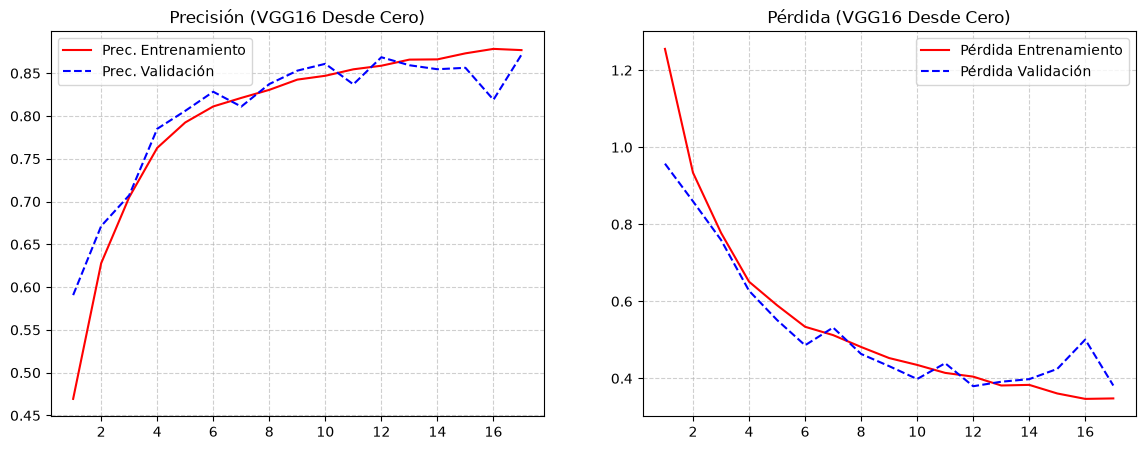

In [11]:
# Extraer datos 
acc = history_vgg_scratch.history['accuracy'] 
val_acc = history_vgg_scratch.history['val_accuracy'] 
loss = history_vgg_scratch.history['loss'] 
val_loss = history_vgg_scratch.history['val_loss'] 
epochs_range = range(1, len(acc) + 1) 

plt.figure(figsize=(14, 5)) 

# Precisión 
plt.subplot(1, 2, 1) 
plt.plot(epochs_range, acc, 'r-', label='Prec. Entrenamiento') 
plt.plot(epochs_range, val_acc, 'b--', label='Prec. Validación') 
plt.title('Precisión (VGG16 Desde Cero)') 
plt.legend() 
plt.grid(True, linestyle='--', alpha=0.6) 

# Pérdida 
plt.subplot(1, 2, 2) 
plt.plot(epochs_range, loss, 'r-', label='Pérdida Entrenamiento') 
plt.plot(epochs_range, val_loss, 'b--', label='Pérdida Validación') 
plt.title('Pérdida (VGG16 Desde Cero)') 
plt.legend() 
plt.grid(True, linestyle='--', alpha=0.6) 

plt.show()

In [12]:
import numpy as np 
from sklearn.metrics import precision_recall_fscore_support, accuracy_score 

print("Procesando métricas para la Tabla de Modelo Desde Cero (VGG16)...") 

# 1. Obtener predicciones del modelo DESDE CERO 
test_generator.reset() 
Y_pred_vgg_scratch = model_vgg_scratch.predict(test_generator, verbose=0) 
y_pred_vgg_scratch = np.argmax(Y_pred_vgg_scratch, axis=1) 
y_true = test_generator.classes 

# 2. Calcular métricas 
acc_test_vgg_scratch = accuracy_score(y_true, y_pred_vgg_scratch) 
prec_vgg_scratch, rec_vgg_scratch, f1_vgg_scratch, _ = precision_recall_fscore_support(y_true, y_pred_vgg_scratch, average='macro') 

# 3. Extraer el Accuracy de Entrenamiento y Validación de la mejor época 
best_epoch_vgg_scratch = np.argmax(history_vgg_scratch.history['val_accuracy']) 
acc_train_vgg_scratch = history_vgg_scratch.history['accuracy'][best_epoch_vgg_scratch] 
acc_val_vgg_scratch = history_vgg_scratch.history['val_accuracy'][best_epoch_vgg_scratch] 
total_epochs_vgg_scratch = len(history_vgg_scratch.history['loss']) 

# 4. Imprimir para la tabla 
print("\n" + "="*70) 
print("TABLA 2: Resumen de las métricas de los modelos entrenados DESDE CERO") 
print("="*70) 
print(f"Modelo                : VGG16 (Scratch)") 
print(f"Learning rate         : 1e-4") 
print(f"Epocas                : {total_epochs_vgg_scratch} (Mejor época: {best_epoch_vgg_scratch + 1})") 
print(f"Optimizador           : Adam") 
print(f"Accuracy Entrenamiento: {acc_train_vgg_scratch:.4f}") 
print(f"Accuracy Validación   : {acc_val_vgg_scratch:.4f}") 
print(f"Accuracy Prueba       : {acc_test_vgg_scratch:.4f}") 
print(f"Precision (macro)     : {prec_vgg_scratch:.4f}") 
print(f"Recall (macro)        : {rec_vgg_scratch:.4f}") 
print(f"F1-score (macro)      : {f1_vgg_scratch:.4f}") 
print("="*70)

Procesando métricas para la Tabla de Modelo Desde Cero (VGG16)...

TABLA 2: Resumen de las métricas de los modelos entrenados DESDE CERO
Modelo                : VGG16 (Scratch)
Learning rate         : 1e-4
Epocas                : 17 (Mejor época: 17)
Optimizador           : Adam
Accuracy Entrenamiento: 0.8770
Accuracy Validación   : 0.8717
Accuracy Prueba       : 0.8687
Precision (macro)     : 0.8704
Recall (macro)        : 0.8723
F1-score (macro)      : 0.8700


In [13]:
print("Cargando VGG16 CON Transfer Learning...") 

# 1. Cargar pesos de ImageNet 
base_model_vgg_tl = VGG16( 
    weights='imagenet', 
    include_top=False, 
    input_shape=(150, 150, 3) 
) 

# 2. Congelar el modelo base 
base_model_vgg_tl.trainable = False 

# 3. Construir el nuevo modelo 
model_vgg_tl = Sequential([ 
    base_model_vgg_tl, 
    GlobalAveragePooling2D(), 
    Dropout(0.5), 
    Dense(6, activation='softmax') 
]) 

# 4. Compilar 
model_vgg_tl.compile( 
    optimizer=Adam(learning_rate=1e-4), 
    loss='categorical_crossentropy', 
    metrics=['accuracy'] 
) 

# 5. Callbacks 
callbacks_vgg_tl = [ 
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True), 
    ModelCheckpoint('vgg16_tl_best.keras', monitor='val_loss', save_best_only=True, verbose=1) 
] 

print("Iniciando entrenamiento (Feature Extraction)...") 

# 6. Entrenamiento 
history_vgg_tl = model_vgg_tl.fit( 
    train_generator, 
    epochs=15, 
    validation_data=test_generator, 
    callbacks=callbacks_vgg_tl, 
    verbose=1 
) 
print("¡Entrenamiento Transfer Learning finalizado!")

Cargando VGG16 CON Transfer Learning...
58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 21s 0us/step
Iniciando entrenamiento (Feature Extraction)...
Epoch 1/15


I0000 00:00:1784782398.160220    4597 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_50963__.70


208/439 ━━━━━━━━━━━━━━━━━━━━ 1:48 469ms/step - accuracy: 0.2049 - loss: 1.8750

I0000 00:00:1784782499.555525    4595 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_50963__.70


439/439 ━━━━━━━━━━━━━━━━━━━━ 0s 423ms/step - accuracy: 0.2529 - loss: 1.7662
Epoch 1: val_loss improved from None to 1.48893, saving model to vgg16_tl_best.keras

Epoch 1: finished saving model to vgg16_tl_best.keras
439/439 ━━━━━━━━━━━━━━━━━━━━ 219s 485ms/step - accuracy: 0.2529 - loss: 1.7662 - val_accuracy: 0.5070 - val_loss: 1.4889
Epoch 2/15
439/439 ━━━━━━━━━━━━━━━━━━━━ 0s 348ms/step - accuracy: 0.4179 - loss: 1.4609
Epoch 2: val_loss improved from 1.48893 to 1.26834, saving model to vgg16_tl_best.keras

Epoch 2: finished saving model to vgg16_tl_best.keras
439/439 ━━━━━━━━━━━━━━━━━━━━ 176s 400ms/step - accuracy: 0.4179 - loss: 1.4609 - val_accuracy: 0.6647 - val_loss: 1.2683
Epoch 3/15
439/439 ━━━━━━━━━━━━━━━━━━━━ 0s 350ms/step - accuracy: 0.5249 - loss: 1.2717
Epoch 3: val_loss improved from 1.26834 to 1.12038, saving model to vgg16_tl_best.keras

Epoch 3: finished saving model to vgg16_tl_best.keras
439/439 ━━━━━━━━━━━━━━━━━━━━ 175s 399ms/step - accuracy: 0.5249 - loss: 1.2717 

In [14]:
print("Preparando VGG16 para Fine-Tuning...") 

# 1. Descongelar temporalmente todo 
base_model_vgg_tl.trainable = True 

# 2. Congelar todo EXCEPTO las capas del último bloque ('block5') 
for layer in base_model_vgg_tl.layers: 
    if layer.name.startswith('block5'): 
        layer.trainable = True 
    else: 
        layer.trainable = False 
        
# 3. Re-compilar con learning rate muy bajo (1e-5) 
model_vgg_tl.compile( 
    optimizer=Adam(learning_rate=1e-5), 
    loss='categorical_crossentropy', 
    metrics=['accuracy'] 
) 

# 4. Callbacks 
callbacks_vgg_ft = [ 
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True), 
    ModelCheckpoint('vgg16_finetuning_best.keras', monitor='val_loss', save_best_only=True, verbose=1) 
] 

print("Iniciando entrenamiento de Fine-Tuning...") 

# 5. Entrenamiento 
history_vgg_ft = model_vgg_tl.fit( 
    train_generator, 
    epochs=15, 
    validation_data=test_generator, 
    callbacks=callbacks_vgg_ft, 
    verbose=1 
) 
print("¡Fine-Tuning con VGG16 finalizado!")

Preparando VGG16 para Fine-Tuning...
Iniciando entrenamiento de Fine-Tuning...
Epoch 1/15


I0000 00:00:1784784975.981910    4596 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_88038__.70


437/439 ━━━━━━━━━━━━━━━━━━━━ 0s 298ms/step - accuracy: 0.8118 - loss: 0.5137

I0000 00:00:1784785109.905078    4596 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_88038__.70


439/439 ━━━━━━━━━━━━━━━━━━━━ 0s 304ms/step - accuracy: 0.8119 - loss: 0.5135
Epoch 1: val_loss improved from None to 0.35593, saving model to vgg16_finetuning_best.keras

Epoch 1: finished saving model to vgg16_finetuning_best.keras
439/439 ━━━━━━━━━━━━━━━━━━━━ 163s 358ms/step - accuracy: 0.8119 - loss: 0.5135 - val_accuracy: 0.8717 - val_loss: 0.3559
Epoch 2/15
439/439 ━━━━━━━━━━━━━━━━━━━━ 0s 337ms/step - accuracy: 0.8635 - loss: 0.3877
Epoch 2: val_loss improved from 0.35593 to 0.30886, saving model to vgg16_finetuning_best.keras

Epoch 2: finished saving model to vgg16_finetuning_best.keras
439/439 ━━━━━━━━━━━━━━━━━━━━ 171s 388ms/step - accuracy: 0.8635 - loss: 0.3877 - val_accuracy: 0.8910 - val_loss: 0.3089
Epoch 3/15
439/439 ━━━━━━━━━━━━━━━━━━━━ 0s 338ms/step - accuracy: 0.8812 - loss: 0.3403
Epoch 3: val_loss improved from 0.30886 to 0.29029, saving model to vgg16_finetuning_best.keras

Epoch 3: finished saving model to vgg16_finetuning_best.keras
439/439 ━━━━━━━━━━━━━━━━━━━━ 17

Evaluando VGG16 (Fine-Tuned) en el conjunto de prueba...
94/94 ━━━━━━━━━━━━━━━━━━━━ 26s 255ms/step

REPORTE DE CLASIFICACIÓN - VGG16 (FINE-TUNING)
              precision    recall  f1-score   support

   buildings     0.8858    0.9405    0.9123       437
      forest     0.9752    0.9958    0.9854       474
     glacier     0.8625    0.8734    0.8679       553
    mountain     0.8926    0.8552    0.8735       525
         sea     0.9431    0.9431    0.9431       510
      street     0.9415    0.9002    0.9204       501

    accuracy                         0.9157      3000
   macro avg     0.9168    0.9180    0.9171      3000
weighted avg     0.9159    0.9157    0.9155      3000



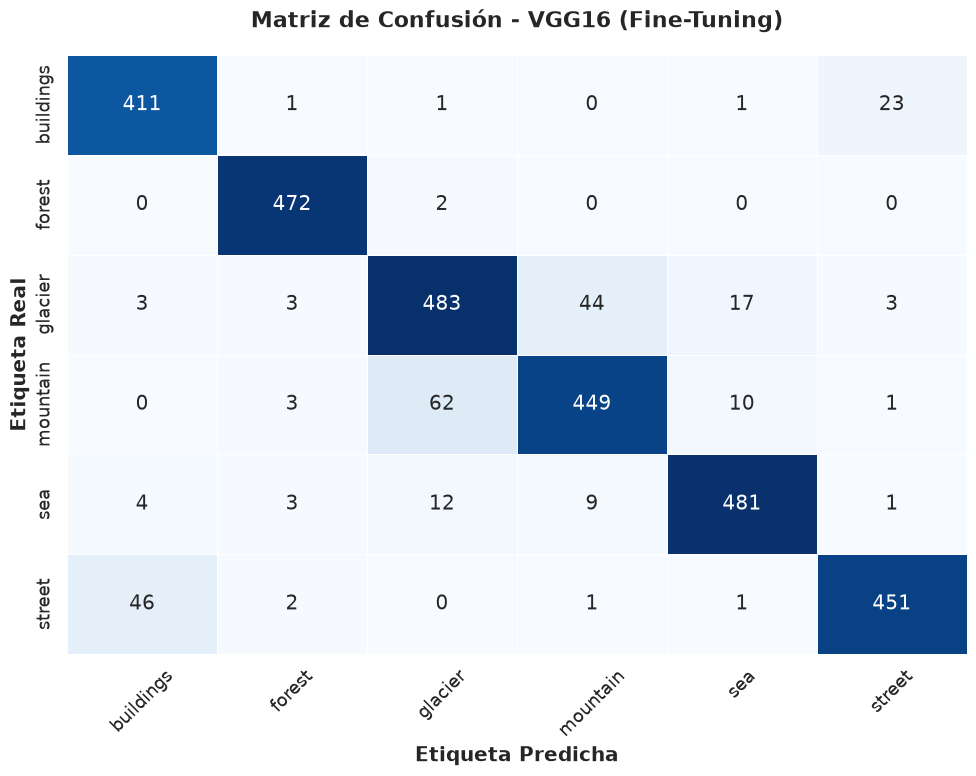

In [15]:
import numpy as np 
import seaborn as sns 
from sklearn.metrics import classification_report, confusion_matrix 

print("Evaluando VGG16 (Fine-Tuned) en el conjunto de prueba...") 

# 1. Reiniciar generador 
test_generator.reset() 

# 2. Obtener predicciones 
Y_pred_vgg = model_vgg_tl.predict(test_generator, verbose=1) 
y_pred_vgg = np.argmax(Y_pred_vgg, axis=1) 
y_true = test_generator.classes 
nombres_clases = list(test_generator.class_indices.keys()) 

# 3. Reporte de Clasificación (Para tu Tabla 3) 
print("\n" + "="*50) 
print("REPORTE DE CLASIFICACIÓN - VGG16 (FINE-TUNING)") 
print("="*50) 
print(classification_report(y_true, y_pred_vgg, target_names=nombres_clases, digits=4)) 

# 4. Matriz de Confusión 
cm_vgg = confusion_matrix(y_true, y_pred_vgg) 

plt.figure(figsize=(10, 8)) 
sns.set(font_scale=1.2) 
sns.heatmap( 
    cm_vgg, 
    annot=True, 
    fmt='d', 
    cmap='Blues', # Usamos Azul para contrastar con el Verde de ResNet50
    xticklabels=nombres_clases, 
    yticklabels=nombres_clases, 
    linewidths=.5, 
    cbar=False 
) 

plt.ylabel('Etiqueta Real', fontweight='bold') 
plt.xlabel('Etiqueta Predicha', fontweight='bold') 
plt.title('Matriz de Confusión - VGG16 (Fine-Tuning)', fontsize=16, fontweight='bold', pad=20) 
plt.xticks(rotation=45) 
plt.tight_layout() 
plt.show()

In [16]:
import numpy as np 
from sklearn.metrics import precision_recall_fscore_support, accuracy_score 

print("Procesando métricas para la Tabla de Modelo Preentrenado (Fine-Tuning VGG16)...") 

# 1. Obtener predicciones del modelo FINE-TUNING 
test_generator.reset() 
Y_pred_vgg_tl = model_vgg_tl.predict(test_generator, verbose=0) 
y_pred_vgg_tl = np.argmax(Y_pred_vgg_tl, axis=1) 
y_true = test_generator.classes 

# 2. Calcular métricas 
acc_test_vgg_tl = accuracy_score(y_true, y_pred_vgg_tl) 
prec_vgg_tl, rec_vgg_tl, f1_vgg_tl, _ = precision_recall_fscore_support(y_true, y_pred_vgg_tl, average='macro') 

# 3. Extraer el Accuracy de Entrenamiento y Validación de la mejor época del Fine-Tuning 
best_epoch_vgg_tl = np.argmax(history_vgg_ft.history['val_accuracy']) 
acc_train_vgg_tl = history_vgg_ft.history['accuracy'][best_epoch_vgg_tl] 
acc_val_vgg_tl = history_vgg_ft.history['val_accuracy'][best_epoch_vgg_tl] 
total_epochs_vgg_tl = len(history_vgg_ft.history['loss']) 

# 4. Imprimir para la tabla 
print("\n" + "="*70) 
print("TABLA 1: Resumen de las métricas del modelo PREENTRENADO (Fine-Tuning VGG16)") 
print("="*70) 
print(f"Modelo                : VGG16 (Fine-Tuning)") 
print(f"Image Batch           : {test_generator.batch_size}") 
print(f"Epocas                : {total_epochs_vgg_tl} (Mejor época: {best_epoch_vgg_tl + 1})") 
print(f"Optimizador           : Adam (lr=1e-5)") 
print(f"Accuracy Entrenamiento: {acc_train_vgg_tl:.4f}") 
print(f"Accuracy Validación   : {acc_val_vgg_tl:.4f}") 
print(f"Accuracy Prueba       : {acc_test_vgg_tl:.4f}") 
print(f"Precision (macro)     : {prec_vgg_tl:.4f}") 
print(f"Recall (macro)        : {rec_vgg_tl:.4f}") 
print(f"F1-score (macro)      : {f1_vgg_tl:.4f}") 
print("="*70)

Procesando métricas para la Tabla de Modelo Preentrenado (Fine-Tuning VGG16)...

TABLA 1: Resumen de las métricas del modelo PREENTRENADO (Fine-Tuning VGG16)
Modelo                : VGG16 (Fine-Tuning)
Image Batch           : 32
Epocas                : 15 (Mejor época: 12)
Optimizador           : Adam (lr=1e-5)
Accuracy Entrenamiento: 0.9266
Accuracy Validación   : 0.9200
Accuracy Prueba       : 0.9157
Precision (macro)     : 0.9168
Recall (macro)        : 0.9180
F1-score (macro)      : 0.9171


Celda 1: InceptionV3 Sin Transfer Learning (Desde Cero)

In [ ]:
from tensorflow.keras.applications import InceptionV3
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
import matplotlib.pyplot as plt

print("Cargando InceptionV3 SIN Transfer Learning (Desde cero)...")

# 1. Cargar InceptionV3 en blanco (weights=None)
base_model_inc_scratch = InceptionV3(
    weights=None, 
    include_top=False, 
    input_shape=(150, 150, 3)
)

# Queremos que toda la red aprenda desde cero
base_model_inc_scratch.trainable = True 

# 2. Construir el modelo
model_inc_scratch = Sequential([
    base_model_inc_scratch,
    GlobalAveragePooling2D(),
    Dropout(0.5),
    Dense(6, activation='softmax')
])

# 3. Compilar
model_inc_scratch.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# 4. Callbacks
callbacks_inc_scratch = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    ModelCheckpoint('inceptionv3_scratch_best.keras', monitor='val_loss', save_best_only=True, verbose=1)
]

print("Iniciando entrenamiento de InceptionV3 Sin Transfer Learning...")

# 5. Entrenamiento
history_inc_scratch = model_inc_scratch.fit(
    train_generator,
    epochs=20,
    validation_data=test_generator,
    callbacks=callbacks_inc_scratch,
    verbose=1
)
print("¡Entrenamiento finalizado!")

Gráficas de InceptionV3 (Desde Cero)

In [ ]:
# Extraer datos 
acc = history_inc_scratch.history['accuracy'] 
val_acc = history_inc_scratch.history['val_accuracy'] 
loss = history_inc_scratch.history['loss'] 
val_loss = history_inc_scratch.history['val_loss'] 
epochs_range = range(1, len(acc) + 1) 

plt.figure(figsize=(14, 5)) 

# Precisión 
plt.subplot(1, 2, 1) 
plt.plot(epochs_range, acc, 'r-', label='Prec. Entrenamiento') 
plt.plot(epochs_range, val_acc, 'b--', label='Prec. Validación') 
plt.title('Precisión (InceptionV3 Desde Cero)') 
plt.legend() 
plt.grid(True, linestyle='--', alpha=0.6) 

# Pérdida 
plt.subplot(1, 2, 2) 
plt.plot(epochs_range, loss, 'r-', label='Pérdida Entrenamiento') 
plt.plot(epochs_range, val_loss, 'b--', label='Pérdida Validación') 
plt.title('Pérdida (InceptionV3 Desde Cero)') 
plt.legend() 
plt.grid(True, linestyle='--', alpha=0.6) 

plt.show()

Métricas del modelo Desde Cero (Tabla 2)

In [ ]:
import numpy as np 
from sklearn.metrics import precision_recall_fscore_support, accuracy_score 

print("Procesando métricas para la Tabla de Modelo Desde Cero (InceptionV3)...") 

# 1. Obtener predicciones del modelo DESDE CERO 
test_generator.reset() 
Y_pred_inc_scratch = model_inc_scratch.predict(test_generator, verbose=0) 
y_pred_inc_scratch = np.argmax(Y_pred_inc_scratch, axis=1) 
y_true = test_generator.classes 

# 2. Calcular métricas 
acc_test_inc_scratch = accuracy_score(y_true, y_pred_inc_scratch) 
prec_inc_scratch, rec_inc_scratch, f1_inc_scratch, _ = precision_recall_fscore_support(y_true, y_pred_inc_scratch, average='macro') 

# 3. Extraer el Accuracy de Entrenamiento y Validación de la mejor época 
best_epoch_inc_scratch = np.argmax(history_inc_scratch.history['val_accuracy']) 
acc_train_inc_scratch = history_inc_scratch.history['accuracy'][best_epoch_inc_scratch] 
acc_val_inc_scratch = history_inc_scratch.history['val_accuracy'][best_epoch_inc_scratch] 
total_epochs_inc_scratch = len(history_inc_scratch.history['loss']) 

# 4. Imprimir para la tabla 
print("\n" + "="*70) 
print("TABLA 2: Resumen de las métricas de los modelos entrenados DESDE CERO") 
print("="*70) 
print(f"Modelo                : InceptionV3 (Scratch)") 
print(f"Learning rate         : 1e-4") 
print(f"Epocas                : {total_epochs_inc_scratch} (Mejor época: {best_epoch_inc_scratch + 1})") 
print(f"Optimizador           : Adam") 
print(f"Accuracy Entrenamiento: {acc_train_inc_scratch:.4f}") 
print(f"Accuracy Validación   : {acc_val_inc_scratch:.4f}") 
print(f"Accuracy Prueba       : {acc_test_inc_scratch:.4f}") 
print(f"Precision (macro)     : {prec_inc_scratch:.4f}") 
print(f"Recall (macro)        : {rec_inc_scratch:.4f}") 
print(f"F1-score (macro)      : {f1_inc_scratch:.4f}") 
print("="*70)

InceptionV3 Con Transfer Learning (Feature Extraction)

In [ ]:
print("Cargando InceptionV3 CON Transfer Learning...") 

# 1. Cargar pesos de ImageNet 
base_model_inc_tl = InceptionV3( 
    weights='imagenet', 
    include_top=False, 
    input_shape=(150, 150, 3) 
) 

# 2. Congelar el modelo base 
base_model_inc_tl.trainable = False 

# 3. Construir el nuevo modelo 
model_inc_tl = Sequential([ 
    base_model_inc_tl, 
    GlobalAveragePooling2D(), 
    Dropout(0.5), 
    Dense(6, activation='softmax') 
]) 

# 4. Compilar 
model_inc_tl.compile( 
    optimizer=Adam(learning_rate=1e-4), 
    loss='categorical_crossentropy', 
    metrics=['accuracy'] 
) 

# 5. Callbacks 
callbacks_inc_tl = [ 
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True), 
    ModelCheckpoint('inceptionv3_tl_best.keras', monitor='val_loss', save_best_only=True, verbose=1) 
] 

print("Iniciando entrenamiento (Feature Extraction)...") 

# 6. Entrenamiento 
history_inc_tl = model_inc_tl.fit( 
    train_generator, 
    epochs=15, 
    validation_data=test_generator, 
    callbacks=callbacks_inc_tl, 
    verbose=1 
) 
print("¡Entrenamiento Transfer Learning finalizado!")

InceptionV3 Con Fine-Tuning

In [ ]:
print("Preparando InceptionV3 para Fine-Tuning...") 

# 1. Descongelar temporalmente todo 
base_model_inc_tl.trainable = True 

# 2. Congelar todo EXCEPTO las capas del último bloque ('mixed10') 
for layer in base_model_inc_tl.layers: 
    if layer.name.startswith('mixed10'): 
        layer.trainable = True 
    else: 
        layer.trainable = False 
        
# 3. Re-compilar con learning rate muy bajo (1e-5) 
model_inc_tl.compile( 
    optimizer=Adam(learning_rate=1e-5), 
    loss='categorical_crossentropy', 
    metrics=['accuracy'] 
) 

# 4. Callbacks 
callbacks_inc_ft = [ 
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True), 
    ModelCheckpoint('inceptionv3_finetuning_best.keras', monitor='val_loss', save_best_only=True, verbose=1) 
] 

print("Iniciando entrenamiento de Fine-Tuning...") 

# 5. Entrenamiento 
history_inc_ft = model_inc_tl.fit( 
    train_generator, 
    epochs=15, 
    validation_data=test_generator, 
    callbacks=callbacks_inc_ft, 
    verbose=1 
) 
print("¡Fine-Tuning con InceptionV3 finalizado!")

Métricas y Matriz de Confusión (Fine-Tuning InceptionV3)

In [ ]:
import numpy as np 
import seaborn as sns 
from sklearn.metrics import classification_report, confusion_matrix 

print("Evaluando InceptionV3 (Fine-Tuned) en el conjunto de prueba...") 

# 1. Reiniciar generador 
test_generator.reset() 

# 2. Obtener predicciones 
Y_pred_inc = model_inc_tl.predict(test_generator, verbose=1) 
y_pred_inc = np.argmax(Y_pred_inc, axis=1) 
y_true = test_generator.classes 
nombres_clases = list(test_generator.class_indices.keys()) 

# 3. Reporte de Clasificación (Para tu Tabla 3) 
print("\n" + "="*50) 
print("REPORTE DE CLASIFICACIÓN - INCEPTIONV3 (FINE-TUNING)") 
print("="*50) 
print(classification_report(y_true, y_pred_inc, target_names=nombres_clases, digits=4)) 

# 4. Matriz de Confusión 
cm_inc = confusion_matrix(y_true, y_pred_inc) 

plt.figure(figsize=(10, 8)) 
sns.set(font_scale=1.2) 
sns.heatmap( 
    cm_inc, 
    annot=True, 
    fmt='d', 
    cmap='Oranges', # Usamos Naranja para contrastar con el Verde de ResNet50 y Azul de VGG16
    xticklabels=nombres_clases, 
    yticklabels=nombres_clases, 
    linewidths=.5, 
    cbar=False 
) 

plt.ylabel('Etiqueta Real', fontweight='bold') 
plt.xlabel('Etiqueta Predicha', fontweight='bold') 
plt.title('Matriz de Confusión - InceptionV3 (Fine-Tuning)', fontsize=16, fontweight='bold', pad=20) 
plt.xticks(rotation=45) 
plt.tight_layout() 
plt.show()

Resultados del modelo Preentrenado (Tabla 1)

In [ ]:
import numpy as np 
from sklearn.metrics import precision_recall_fscore_support, accuracy_score 

print("Procesando métricas para la Tabla de Modelo Preentrenado (Fine-Tuning InceptionV3)...") 

# 1. Obtener predicciones del modelo FINE-TUNING 
test_generator.reset() 
Y_pred_inc_tl = model_inc_tl.predict(test_generator, verbose=0) 
y_pred_inc_tl = np.argmax(Y_pred_inc_tl, axis=1) 
y_true = test_generator.classes 

# 2. Calcular métricas 
acc_test_inc_tl = accuracy_score(y_true, y_pred_inc_tl) 
prec_inc_tl, rec_inc_tl, f1_inc_tl, _ = precision_recall_fscore_support(y_true, y_pred_inc_tl, average='macro') 

# 3. Extraer el Accuracy de Entrenamiento y Validación de la mejor época del Fine-Tuning 
best_epoch_inc_tl = np.argmax(history_inc_ft.history['val_accuracy']) 
acc_train_inc_tl = history_inc_ft.history['accuracy'][best_epoch_inc_tl] 
acc_val_inc_tl = history_inc_ft.history['val_accuracy'][best_epoch_inc_tl] 
total_epochs_inc_tl = len(history_inc_ft.history['loss']) 

# 4. Imprimir para la tabla 
print("\n" + "="*70) 
print("TABLA 1: Resumen de las métricas del modelo PREENTRENADO (Fine-Tuning InceptionV3)") 
print("="*70) 
print(f"Modelo                : InceptionV3 (Fine-Tuning)") 
print(f"Image Batch           : {test_generator.batch_size}") 
print(f"Epocas                : {total_epochs_inc_tl} (Mejor época: {best_epoch_inc_tl + 1})") 
print(f"Optimizador           : Adam (lr=1e-5)") 
print(f"Accuracy Entrenamiento: {acc_train_inc_tl:.4f}") 
print(f"Accuracy Validación   : {acc_val_inc_tl:.4f}") 
print(f"Accuracy Prueba       : {acc_test_inc_tl:.4f}") 
print(f"Precision (macro)     : {prec_inc_tl:.4f}") 
print(f"Recall (macro)        : {rec_inc_tl:.4f}") 
print(f"F1-score (macro)      : {f1_inc_tl:.4f}") 
print("="*70)

MobileNetV2 Sin Transfer Learning (Desde Cero)

In [ ]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
import matplotlib.pyplot as plt

print("Cargando MobileNetV2 SIN Transfer Learning (Desde cero)...")

# 1. Cargar MobileNetV2 en blanco (weights=None)
base_model_mob_scratch = MobileNetV2(
    weights=None, 
    include_top=False, 
    input_shape=(150, 150, 3)
)

# Queremos que toda la red aprenda desde cero
base_model_mob_scratch.trainable = True 

# 2. Construir el modelo
model_mob_scratch = Sequential([
    base_model_mob_scratch,
    GlobalAveragePooling2D(),
    Dropout(0.5),
    Dense(6, activation='softmax')
])

# 3. Compilar
model_mob_scratch.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# 4. Callbacks
callbacks_mob_scratch = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    ModelCheckpoint('mobilenetv2_scratch_best.keras', monitor='val_loss', save_best_only=True, verbose=1)
]

print("Iniciando entrenamiento de MobileNetV2 Sin Transfer Learning...")

# 5. Entrenamiento
history_mob_scratch = model_mob_scratch.fit(
    train_generator,
    epochs=20,
    validation_data=test_generator,
    callbacks=callbacks_mob_scratch,
    verbose=1
)
print("¡Entrenamiento finalizado!")

Gráficas de MobileNetV2 (Desde Cero)

In [ ]:
# Extraer datos 
acc = history_mob_scratch.history['accuracy'] 
val_acc = history_mob_scratch.history['val_accuracy'] 
loss = history_mob_scratch.history['loss'] 
val_loss = history_mob_scratch.history['val_loss'] 
epochs_range = range(1, len(acc) + 1) 

plt.figure(figsize=(14, 5)) 

# Precisión 
plt.subplot(1, 2, 1) 
plt.plot(epochs_range, acc, 'r-', label='Prec. Entrenamiento') 
plt.plot(epochs_range, val_acc, 'b--', label='Prec. Validación') 
plt.title('Precisión (MobileNetV2 Desde Cero)') 
plt.legend() 
plt.grid(True, linestyle='--', alpha=0.6) 

# Pérdida 
plt.subplot(1, 2, 2) 
plt.plot(epochs_range, loss, 'r-', label='Pérdida Entrenamiento') 
plt.plot(epochs_range, val_loss, 'b--', label='Pérdida Validación') 
plt.title('Pérdida (MobileNetV2 Desde Cero)') 
plt.legend() 
plt.grid(True, linestyle='--', alpha=0.6) 

plt.show()

Métricas del modelo Desde Cero (Tabla 2)

In [ ]:
import numpy as np 
from sklearn.metrics import precision_recall_fscore_support, accuracy_score 

print("Procesando métricas para la Tabla de Modelo Desde Cero (MobileNetV2)...") 

# 1. Obtener predicciones del modelo DESDE CERO 
test_generator.reset() 
Y_pred_mob_scratch = model_mob_scratch.predict(test_generator, verbose=0) 
y_pred_mob_scratch = np.argmax(Y_pred_mob_scratch, axis=1) 
y_true = test_generator.classes 

# 2. Calcular métricas 
acc_test_mob_scratch = accuracy_score(y_true, y_pred_mob_scratch) 
prec_mob_scratch, rec_mob_scratch, f1_mob_scratch, _ = precision_recall_fscore_support(y_true, y_pred_mob_scratch, average='macro') 

# 3. Extraer el Accuracy de Entrenamiento y Validación de la mejor época 
best_epoch_mob_scratch = np.argmax(history_mob_scratch.history['val_accuracy']) 
acc_train_mob_scratch = history_mob_scratch.history['accuracy'][best_epoch_mob_scratch] 
acc_val_mob_scratch = history_mob_scratch.history['val_accuracy'][best_epoch_mob_scratch] 
total_epochs_mob_scratch = len(history_mob_scratch.history['loss']) 

# 4. Imprimir para la tabla 
print("\n" + "="*70) 
print("TABLA 2: Resumen de las métricas de los modelos entrenados DESDE CERO") 
print("="*70) 
print(f"Modelo                : MobileNetV2 (Scratch)") 
print(f"Learning rate         : 1e-4") 
print(f"Epocas                : {total_epochs_mob_scratch} (Mejor época: {best_epoch_mob_scratch + 1})") 
print(f"Optimizador           : Adam") 
print(f"Accuracy Entrenamiento: {acc_train_mob_scratch:.4f}") 
print(f"Accuracy Validación   : {acc_val_mob_scratch:.4f}") 
print(f"Accuracy Prueba       : {acc_test_mob_scratch:.4f}") 
print(f"Precision (macro)     : {prec_mob_scratch:.4f}") 
print(f"Recall (macro)        : {rec_mob_scratch:.4f}") 
print(f"F1-score (macro)      : {f1_mob_scratch:.4f}") 
print("="*70)

MobileNetV2 Con Transfer Learning (Feature Extraction)

In [ ]:
print("Cargando MobileNetV2 CON Transfer Learning...") 

# 1. Cargar pesos de ImageNet 
base_model_mob_tl = MobileNetV2( 
    weights='imagenet', 
    include_top=False, 
    input_shape=(150, 150, 3) 
) 

# 2. Congelar el modelo base 
base_model_mob_tl.trainable = False 

# 3. Construir el nuevo modelo 
model_mob_tl = Sequential([ 
    base_model_mob_tl, 
    GlobalAveragePooling2D(), 
    Dropout(0.5), 
    Dense(6, activation='softmax') 
]) 

# 4. Compilar 
model_mob_tl.compile( 
    optimizer=Adam(learning_rate=1e-4), 
    loss='categorical_crossentropy', 
    metrics=['accuracy'] 
) 

# 5. Callbacks 
callbacks_mob_tl = [ 
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True), 
    ModelCheckpoint('mobilenetv2_tl_best.keras', monitor='val_loss', save_best_only=True, verbose=1) 
] 

print("Iniciando entrenamiento (Feature Extraction)...") 

# 6. Entrenamiento 
history_mob_tl = model_mob_tl.fit( 
    train_generator, 
    epochs=15, 
    validation_data=test_generator, 
    callbacks=callbacks_mob_tl, 
    verbose=1 
) 
print("¡Entrenamiento Transfer Learning finalizado!")

MobileNetV2 Con Fine-Tuning

In [ ]:
print("Preparando MobileNetV2 para Fine-Tuning...") 

# 1. Descongelar temporalmente todo 
base_model_mob_tl.trainable = True 

# 2. Congelar todo EXCEPTO el último bloque ('block_16') y la última conv ('Conv_1')
for layer in base_model_mob_tl.layers: 
    if layer.name.startswith('block_16') or layer.name.startswith('Conv_1'): 
        layer.trainable = True 
    else: 
        layer.trainable = False 
        
# 3. Re-compilar con learning rate muy bajo (1e-5) 
model_mob_tl.compile( 
    optimizer=Adam(learning_rate=1e-5), 
    loss='categorical_crossentropy', 
    metrics=['accuracy'] 
) 

# 4. Callbacks 
callbacks_mob_ft = [ 
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True), 
    ModelCheckpoint('mobilenetv2_finetuning_best.keras', monitor='val_loss', save_best_only=True, verbose=1) 
] 

print("Iniciando entrenamiento de Fine-Tuning...") 

# 5. Entrenamiento 
history_mob_ft = model_mob_tl.fit( 
    train_generator, 
    epochs=15, 
    validation_data=test_generator, 
    callbacks=callbacks_mob_ft, 
    verbose=1 
) 
print("¡Fine-Tuning con MobileNetV2 finalizado!")

Métricas y Matriz de Confusión (Fine-Tuning MobileNetV2)

In [ ]:
import numpy as np 
import seaborn as sns 
from sklearn.metrics import classification_report, confusion_matrix 

print("Evaluando MobileNetV2 (Fine-Tuned) en el conjunto de prueba...") 

# 1. Reiniciar generador 
test_generator.reset() 

# 2. Obtener predicciones 
Y_pred_mob = model_mob_tl.predict(test_generator, verbose=1) 
y_pred_mob = np.argmax(Y_pred_mob, axis=1) 
y_true = test_generator.classes 
nombres_clases = list(test_generator.class_indices.keys()) 

# 3. Reporte de Clasificación (Para tu Tabla 3) 
print("\n" + "="*50) 
print("REPORTE DE CLASIFICACIÓN - MOBILENETV2 (FINE-TUNING)") 
print("="*50) 
print(classification_report(y_true, y_pred_mob, target_names=nombres_clases, digits=4)) 

# 4. Matriz de Confusión 
cm_mob = confusion_matrix(y_true, y_pred_mob) 

plt.figure(figsize=(10, 8)) 
sns.set(font_scale=1.2) 
sns.heatmap( 
    cm_mob, 
    annot=True, 
    fmt='d', 
    cmap='Purples', # Usamos Morado para contrastar con Verde, Azul y Naranja
    xticklabels=nombres_clases, 
    yticklabels=nombres_clases, 
    linewidths=.5, 
    cbar=False 
) 

plt.ylabel('Etiqueta Real', fontweight='bold') 
plt.xlabel('Etiqueta Predicha', fontweight='bold') 
plt.title('Matriz de Confusión - MobileNetV2 (Fine-Tuning)', fontsize=16, fontweight='bold', pad=20) 
plt.xticks(rotation=45) 
plt.tight_layout() 
plt.show()

Resultados del modelo Preentrenado (Tabla 1)

In [ ]:
import numpy as np 
from sklearn.metrics import precision_recall_fscore_support, accuracy_score 

print("Procesando métricas para la Tabla de Modelo Preentrenado (Fine-Tuning MobileNetV2)...") 

# 1. Obtener predicciones del modelo FINE-TUNING 
test_generator.reset() 
Y_pred_mob_tl = model_mob_tl.predict(test_generator, verbose=0) 
y_pred_mob_tl = np.argmax(Y_pred_mob_tl, axis=1) 
y_true = test_generator.classes 

# 2. Calcular métricas 
acc_test_mob_tl = accuracy_score(y_true, y_pred_mob_tl) 
prec_mob_tl, rec_mob_tl, f1_mob_tl, _ = precision_recall_fscore_support(y_true, y_pred_mob_tl, average='macro') 

# 3. Extraer el Accuracy de Entrenamiento y Validación de la mejor época del Fine-Tuning 
best_epoch_mob_tl = np.argmax(history_mob_ft.history['val_accuracy']) 
acc_train_mob_tl = history_mob_ft.history['accuracy'][best_epoch_mob_tl] 
acc_val_mob_tl = history_mob_ft.history['val_accuracy'][best_epoch_mob_tl] 
total_epochs_mob_tl = len(history_mob_ft.history['loss']) 

# 4. Imprimir para la tabla 
print("\n" + "="*70) 
print("TABLA 1: Resumen de las métricas del modelo PREENTRENADO (Fine-Tuning MobileNetV2)") 
print("="*70) 
print(f"Modelo                : MobileNetV2 (Fine-Tuning)") 
print(f"Image Batch           : {test_generator.batch_size}") 
print(f"Epocas                : {total_epochs_mob_tl} (Mejor época: {best_epoch_mob_tl + 1})") 
print(f"Optimizador           : Adam (lr=1e-5)") 
print(f"Accuracy Entrenamiento: {acc_train_mob_tl:.4f}") 
print(f"Accuracy Validación   : {acc_val_mob_tl:.4f}") 
print(f"Accuracy Prueba       : {acc_test_mob_tl:.4f}") 
print(f"Precision (macro)     : {prec_mob_tl:.4f}") 
print(f"Recall (macro)        : {rec_mob_tl:.4f}") 
print(f"F1-score (macro)      : {f1_mob_tl:.4f}") 
print("="*70)